# Are the generated power spectra biased? (conditional models)

Question (Nick): in the continuous 2-parameter (Ω_m, σ8) conditional model, are the power spectra still biased?

**Measurement.** For each of the 32 held-out CAMELS cosmologies (sims 900–931), we compare:
- the mean P(k) of the 64 generated draws, with
- the mean P(k) of the 128 real slices of that simulation.

We then average the ratio over cosmologies (geometric mean). The **cosmology scatter** is the spread of that ratio from one held-out cosmology to the next.

**Space.** P(k) is computed on the tanh-normalized maps that the VGG probe sees (log, tanh, center 7.8964, xmax 22.404; shared by all models and the probe). This is the same space as the earlier six-parameter degradation control. It is not the physical field.

**Binning** matches `simdiff_eval.metrics.radial_power_spectrum_2d` (25 linear bins, mean subtracted). We keep bins up to the Nyquist frequency, and convert to k in h/Mpc with a 25 Mpc/h map side.

**Models.** All use the saved held-out samples, k = 64, seed 123:
- continuous Ω_m–σ8, DPM-50 sampler (all 5 N);
- continuous, DDPM-500 sampler (N = 64, 256; from the sampler test);
- class36 (all 5 N);
- six-parameter fresh sweep (same 5 N).


In [1]:
%matplotlib inline
from pathlib import Path
import glob
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

PROJECT_DIR = Path("/home/jiamingp/diffusion_models_repo")
os.chdir(PROJECT_DIR)
for p in (str(PROJECT_DIR / "scripts"), str(PROJECT_DIR)):
    if p not in sys.path:
        sys.path.insert(0, p)
from prepare_nf_conditional_u128_config import DATA_ROOT
from simdiff_eval.probe_eval import load_heldout_real_slices

NB, H, SIDE = 25, 128, 25.0
ky = np.fft.fftfreq(H) * H
kk = np.sqrt(ky[None, :] ** 2 + ky[:, None] ** 2)
valid = kk > 0
edges = np.linspace(kk[valid].min(), kk[valid].max(), NB + 1)
kc = 0.5 * (edges[:-1] + edges[1:])
bin_of = np.clip(np.digitize(kk, edges) - 1, 0, NB - 1)[valid]
counts = np.bincount(bin_of, minlength=NB)
keep = kc <= H // 2                      # up to Nyquist
k_phys = 2 * np.pi * kc / SIDE           # h/Mpc


def pk(images):
    x = images[:, 0].astype(np.float64)
    x = x - x.mean(axis=(1, 2), keepdims=True)
    out = np.empty((len(x), NB))
    for s in range(0, len(x), 512):
        f = np.fft.fft2(x[s:s + 512])
        p = ((f * f.conj()).real / (H * H))[:, valid]
        out[s:s + 512] = np.stack([np.bincount(bin_of, weights=r, minlength=NB) for r in p]) / counts
    return out


norm = dict(np.load("results/nf_conditional_bias_probe/encoder/vgg_mlp_encoder.npz", allow_pickle=True)["normalization"].item())
HELDOUT = np.arange(900, 932)
real, real_theta, real_sim, _ = load_heldout_real_slices(DATA_ROOT, HELDOUT, slices_per_sim=128, norm=norm)
pk_real = pk(real)
real_mean = np.stack([pk_real[real_sim == s].mean(0) for s in HELDOUT])
theta = np.stack([real_theta[real_sim == s][0] for s in HELDOUT])   # (32, 6) raw parameters
print(norm, real.shape)

{'transform': ['log'], 'method': 'tanh', 'center': 7.896381651151516, 'xmax': 22.404052734375, 'norm_fit_slices': 4096} (4096, 1, 128, 128)


In [2]:
SETS = [
    ("continuous DPM-50", "results/nf_conditional_omsig_continuous_200k/samples/*dpm50*.npz"),
    ("continuous DDPM-500", "results/memorization_regime_diagnostics/sampler_test/samples/nf_cond_omsigc*ddpm500*.npz"),
    ("class36 DPM-50", "results/nf_conditional_omsig_class36_200k/samples/*dpm50*.npz"),
    ("six-param DPM-50", "results/nf_conditional_bias_fresh_full_sweep_200k/samples/*_n{n}_*dpm50*.npz"),
]
ratios = {}   # (model, N) -> (32, NB) per-cosmology P_gen / P_real
for model, pattern in SETS:
    paths = sorted({p for n in (64, 256, 1024, 4096, 32768) for p in glob.glob(pattern.replace("{n}", str(n)))})
    for path in paths:
        with np.load(path, allow_pickle=True) as d:
            g, h = d["samples"], d["heldout_indices"].astype(int)
            k, n = int(d["samples_per_cosmology"]), int(d["dataset_size"])
            assert np.array_equal(h, HELDOUT) and np.allclose(d["theta_raw"], theta) and len(g) == 32 * k
        ratios[(model, n)] = pk(g).reshape(32, k, NB).mean(1) / real_mean
half = np.stack([pk_real[real_sim == s][::2].mean(0) / pk_real[real_sim == s][1::2].mean(0) for s in HELDOUT])
sorted(ratios)

[('class36 DPM-50', 64),
 ('class36 DPM-50', 256),
 ('class36 DPM-50', 1024),
 ('class36 DPM-50', 4096),
 ('class36 DPM-50', 32768),
 ('continuous DDPM-500', 64),
 ('continuous DDPM-500', 256),
 ('continuous DPM-50', 64),
 ('continuous DPM-50', 256),
 ('continuous DPM-50', 1024),
 ('continuous DPM-50', 4096),
 ('continuous DPM-50', 32768),
 ('six-param DPM-50', 64),
 ('six-param DPM-50', 256),
 ('six-param DPM-50', 1024),
 ('six-param DPM-50', 4096),
 ('six-param DPM-50', 32768)]

## 1. Ratio of generated to real P(k), averaged over the 32 held-out cosmologies

A ratio of 1 means the generated maps carry the right power on average. The gray dashed line marks 1.

The gray band is a real-vs-real split-half check (64 vs 64 slices of the same simulation). It shows the measurement noise of the ratio itself: under 1%.

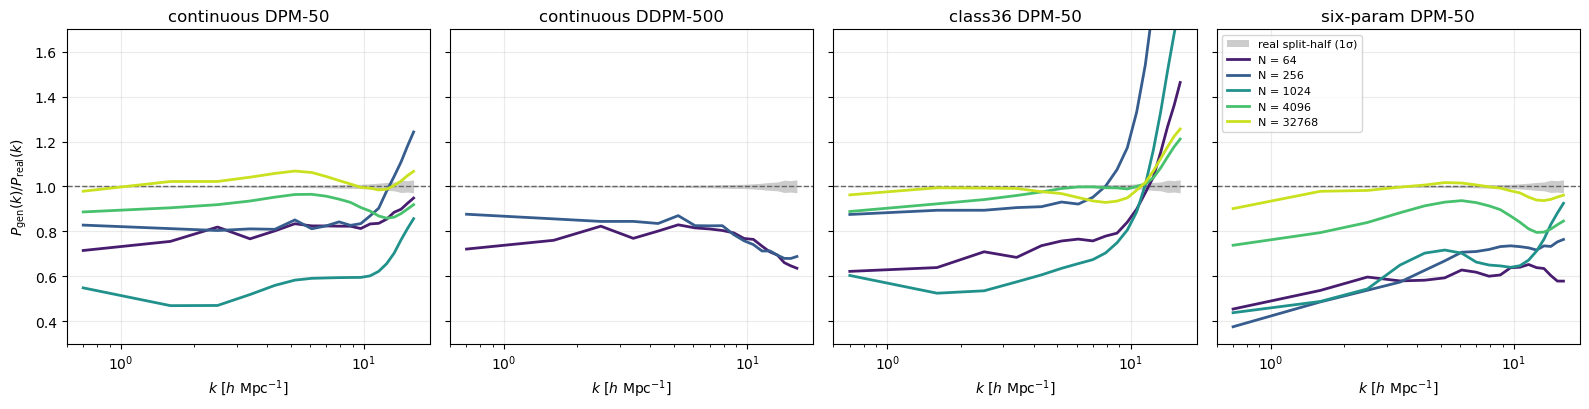

In [3]:
MODELS = [m for m, _ in SETS]
SIZES = [64, 256, 1024, 4096, 32768]
colors = dict(zip(SIZES, plt.get_cmap("viridis")(np.linspace(0.08, 0.92, len(SIZES)))))
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2), sharey=True)
for ax, model in zip(axes, MODELS):
    hl = np.exp(np.log(half[:, keep]).std(0))
    ax.fill_between(k_phys[keep], 1 / hl, hl, color="0.8", lw=0, label="real split-half (1σ)")
    ax.axhline(1, color="0.4", lw=1, ls="--")
    for n in SIZES:
        if (model, n) in ratios:
            r = np.exp(np.log(ratios[(model, n)][:, keep]).mean(0))
            ax.plot(k_phys[keep], r, color=colors[n], lw=2, label=f"N = {n}")
    ax.set_xscale("log")
    ax.set_title(model)
    ax.set_xlabel(r"$k$ [$h$ Mpc$^{-1}$]")
    ax.grid(alpha=0.25)
axes[0].set_ylabel(r"$P_{\rm gen}(k) / P_{\rm real}(k)$")
axes[0].set_ylim(0.3, 1.7)
axes[-1].legend(fontsize=8, loc="upper left")
fig.tight_layout()
display(fig)
plt.close(fig)

## 2. The continuous model alone, with the spread across cosmologies

The shaded band is the 16–84% range of the per-cosmology ratio. A model can match P(k) on average but still be off for individual cosmologies, and those per-cosmology errors are what bias the inferred parameters.

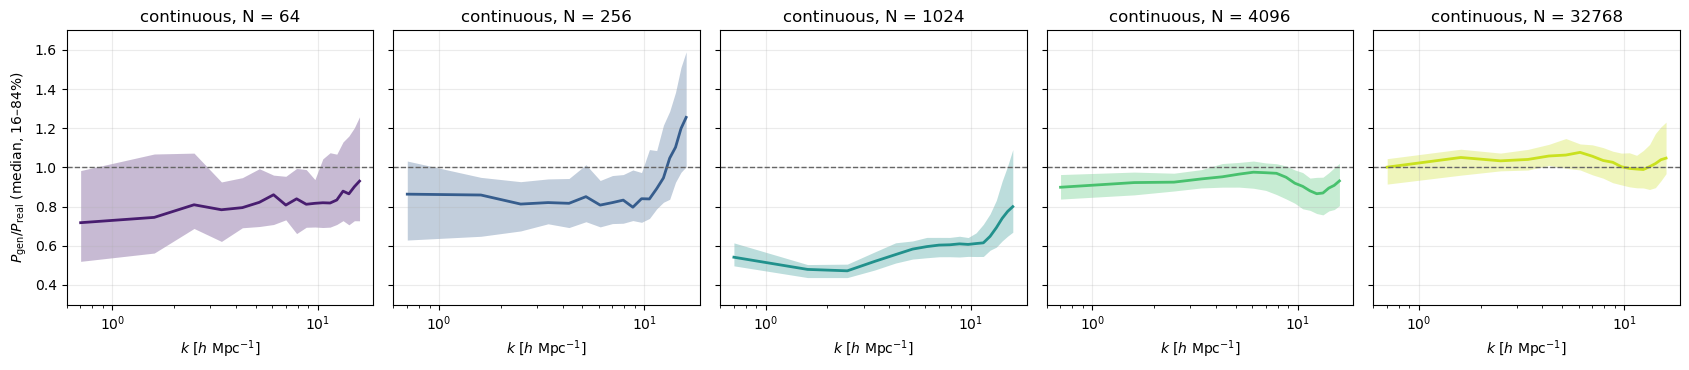

In [4]:
fig, axes = plt.subplots(1, 5, figsize=(17, 3.8), sharey=True)
for ax, n in zip(axes, SIZES):
    lr = np.log(ratios[("continuous DPM-50", n)][:, keep])
    lo, mid, hi = np.exp(np.percentile(lr, [16, 50, 84], axis=0))
    ax.fill_between(k_phys[keep], lo, hi, color=colors[n], alpha=0.3, lw=0)
    ax.plot(k_phys[keep], mid, color=colors[n], lw=2)
    ax.axhline(1, color="0.4", lw=1, ls="--")
    ax.set_xscale("log")
    ax.set_title(f"continuous, N = {n}")
    ax.set_xlabel(r"$k$ [$h$ Mpc$^{-1}$]")
    ax.grid(alpha=0.25)
axes[0].set_ylabel(r"$P_{\rm gen}/P_{\rm real}$ (median, 16–84%)")
axes[0].set_ylim(0.3, 1.7)
fig.tight_layout()
display(fig)
plt.close(fig)

## 3. Summary by scale band

Bands are in Fourier-index units, where Nyquist is 64:

| Band | Fourier index | k [h/Mpc] |
|---|---|---|
| large | < 8 | < 2.0 |
| mid | 8–24 | 2.0–6.0 |
| small | 24–64 | 6.0–16 |

- `mean_ratio`: the geometric mean over cosmologies of P_gen/P_real.
- `scatter_%`: the standard deviation, over cosmologies, of the log-ratio, in %.

The real split-half row is a noise floor for the measurement only. It does **not** include the cosmic variance of a single real simulation box. Each real target is one box, while generated draws are not tied to that box's realization. So part of the roughly 6–9% scatter seen even at N = 32768 can come from the real maps themselves.

In [5]:
BANDS = {"large": kc < 8, "mid": (kc >= 8) & (kc < 24), "small": (kc >= 24) & keep}
rows = []
for label, r in [(("real split-half", 0), half)] + list(ratios.items()):
    for band, m in BANDS.items():
        lr = np.log(r[:, m]).mean(1)
        rows.append(dict(model=label[0], N=label[1], band=band,
                         mean_ratio=np.exp(lr.mean()), **{"scatter_%": 100 * lr.std(ddof=1)}))
table = pd.DataFrame(rows)
summary = table.pivot_table(index=["model", "N"], columns="band", values=["mean_ratio", "scatter_%"], sort=False)
summary = summary.reindex(columns=["large", "mid", "small"], level=1)
summary.style.format({c: ("{:.2f}" if c[0] == "mean_ratio" else "{:.1f}") for c in summary.columns})

## 4. Does the power error depend on cosmology? (continuous model)

Each point is one held-out cosmology: its large-scale (k < 2 h/Mpc) power ratio, plotted against the true Ω_m and σ8. A trend with Ω_m or σ8 would mean the amplitude error is cosmology-dependent. That kind of error biases parameter recovery, not just the overall amplitude.

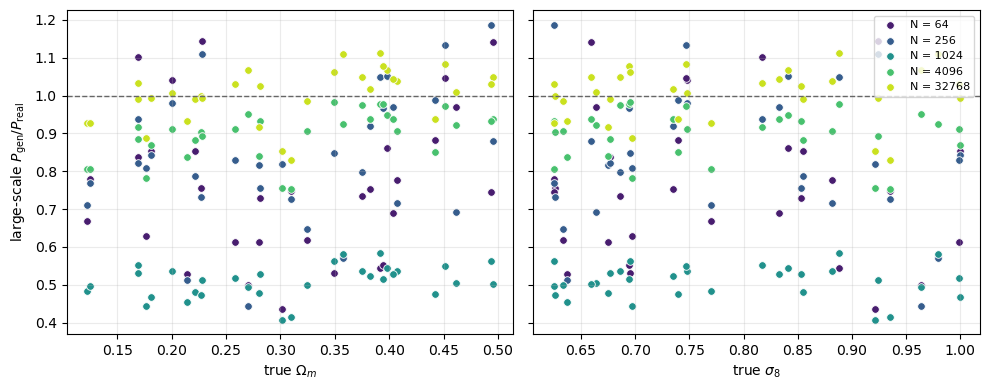

,64,256,1024,4096,32768
corr with Omega_m,0.06,0.30,0.34,0.51,0.43
corr with sigma_8,-0.12,-0.09,-0.03,-0.06,0.09


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, (j, name) in zip(axes, [(0, r"$\Omega_m$"), (1, r"$\sigma_8$")]):
    for n in SIZES:
        r = np.exp(np.log(ratios[("continuous DPM-50", n)][:, BANDS["large"]]).mean(1))
        ax.scatter(theta[:, j], r, color=colors[n], s=30, edgecolor="white", lw=0.6, label=f"N = {n}")
    ax.axhline(1, color="0.4", lw=1, ls="--")
    ax.set_xlabel(f"true {name}")
    ax.grid(alpha=0.25)
axes[0].set_ylabel("large-scale $P_{\\rm gen}/P_{\\rm real}$")
axes[1].legend(fontsize=8)
fig.tight_layout()
display(fig)
plt.close(fig)
corr = {n: [np.corrcoef(theta[:, j], np.log(ratios[("continuous DPM-50", n)][:, BANDS["large"]]).mean(1))[0, 1] for j in (0, 1)]
        for n in SIZES}
pd.DataFrame(corr, index=["corr with Omega_m", "corr with sigma_8"]).round(2)

## Findings

The answer to Nick: **yes, the continuous 2-parameter model's power spectra are still biased low below N = 32768. At N = 32768 they are unbiased.**

Continuous model, DPM-50 sampler, geometric mean over cosmologies of P_gen/P_real:

| N | large | mid | small | Verdict |
|---|---|---|---|---|
| 64 | 0.74 | 0.81 | 0.86 | ~20% deficit |
| 256 | 0.82 | 0.82 | 0.95 | ~20% deficit |
| 1024 | 0.51 | 0.53 | 0.66 | worst: ~45% deficit |
| 4096 | 0.90 | 0.94 | 0.91 | ~5–10% deficit |
| 32768 | 1.00 | 1.05 | 1.02 | consistent with real |

**Compared with the other models:**
- The deficit is milder than in the six-parameter model, which reaches 0.43–0.73 at N ≤ 1024 and 0.77–0.89 at N = 4096.
- The worst case at N = 1024 also appears in class36 (0.56–0.59 at large and mid scales). It sits at the memorization-to-generalization transition.
- The correct DDPM-500 sampler does not fix the deficit at N = 64 and 256. It adds a further small-scale loss (0.73–0.74 vs 0.86–0.95).

**Caveats:**
- This is P(k) of the normalized maps the probe sees, not of the physical field.
- The cosmology scatter is about 6–9% even at N = 32768. Part of it is the cosmic variance of the single real box per cosmology, which the split-half check does not capture.
